# 06 · Machine Learning — 03. Arquetipos de jugador (aprendizaje no supervisado)

Análisis complementario que identifica **subtipos de jugador dentro de cada posición** mediante
clustering K-means sobre los vectores PCA, y los caracteriza por su perfil estadístico y su salario
medio.

## Motivación

El sistema de similitud (06_02) responde a consultas individuales ("¿quién se parece a X?"). Este
análisis aborda una pregunta distinta y de tipo no supervisado: **¿qué tipos de jugador existen en las
grandes ligas, y cuánto cobra cada tipo?**

## Decisiones de diseño

- **Algoritmo:** K-means sobre los vectores PCA (05_03). A diferencia de la búsqueda de vecinos, K-means
  **sí aprende** un modelo (los centroides de los grupos), por lo que constituye un componente de
  aprendizaje no supervisado en sentido estricto.
- **Clustering por posición** (no global): un K-means sobre todas las posiciones juntas se limita a
  reproducir la posición ya conocida (se verificó empíricamente). Segmentando por posición emergen
  **subtipos de estilo** con valor informativo (p. ej. tipos de delantero).
- **Número de clusters K=2 por posición:** determinado mediante un **análisis de silueta detallado**
  (silueta por jugador, no solo la media). Dicho análisis mostró que K=3 introducía en cada posición un
  cluster de baja calidad (con una fracción elevada de jugadores mal asignados), mientras que **K=2
  produce agrupaciones más limpias y equilibradas**. Se prioriza así el criterio estadístico, obteniendo
  dos perfiles claros por posición.
- **Datos:** todas las temporadas (mayor robustez; los arquetipos de estilo son estables en el tiempo).

---

## 1. Imports y carga

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parents[1]
SIM_DIR = ROOT / 'data' / 'modeling' / 'similarity'
FILT_PATH = ROOT / 'data' / 'clean' / 'master_filtered.csv'

of = pd.read_csv(SIM_DIR / 'similitud_outfielders.csv')
of['season'] = of['season'].astype(str)
gk = pd.read_csv(SIM_DIR / 'similitud_keepers.csv')
gk['season'] = gk['season'].astype(str)
PCS = [c for c in of.columns if c.startswith('PC')]
print(f'Outfielders: {of.shape[0]:,} | PCs: {len(PCS)}')
print(f'Porteros:    {gk.shape[0]:,}')

Outfielders: 13,163 | PCs: 17
Porteros:    1,039


## 2. Selección del número de clusters

Para elegir el número de arquetipos (K) por posición no basta con mirar el **coeficiente de silueta medio**,
ya que un promedio alto puede ocultar clusters de baja calidad (con muchos puntos mal asignados). Se realiza
un **análisis de silueta detallado** (siguiendo la metodología de scikit-learn): para cada K candidato se
representa la silueta de *cada jugador* agrupada por cluster, lo que permite ver el tamaño y la calidad
interna de cada grupo, no solo su media.

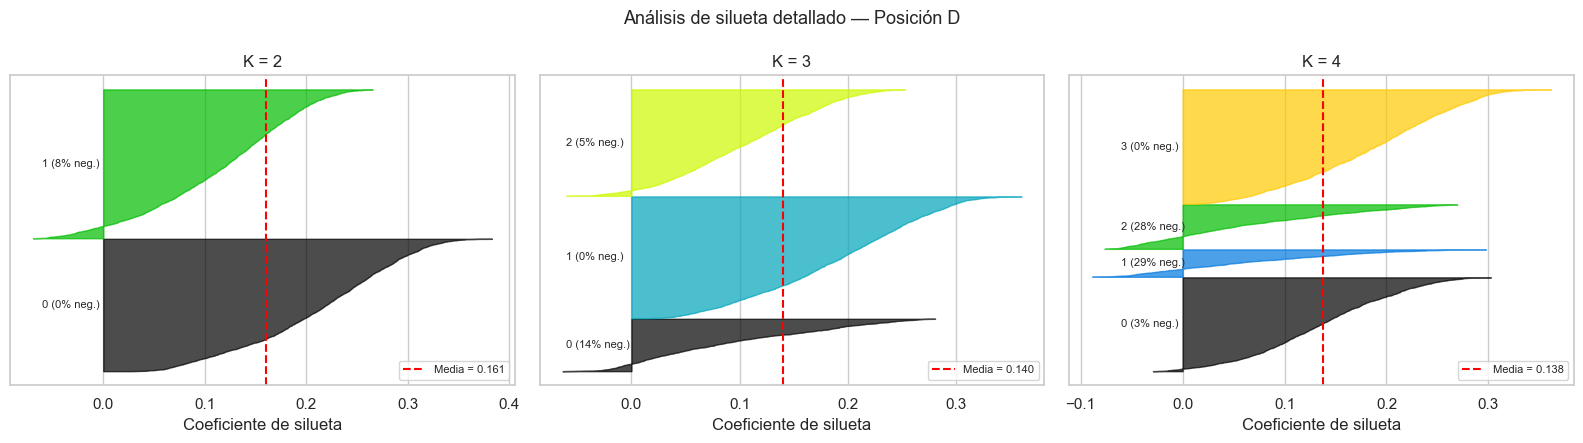

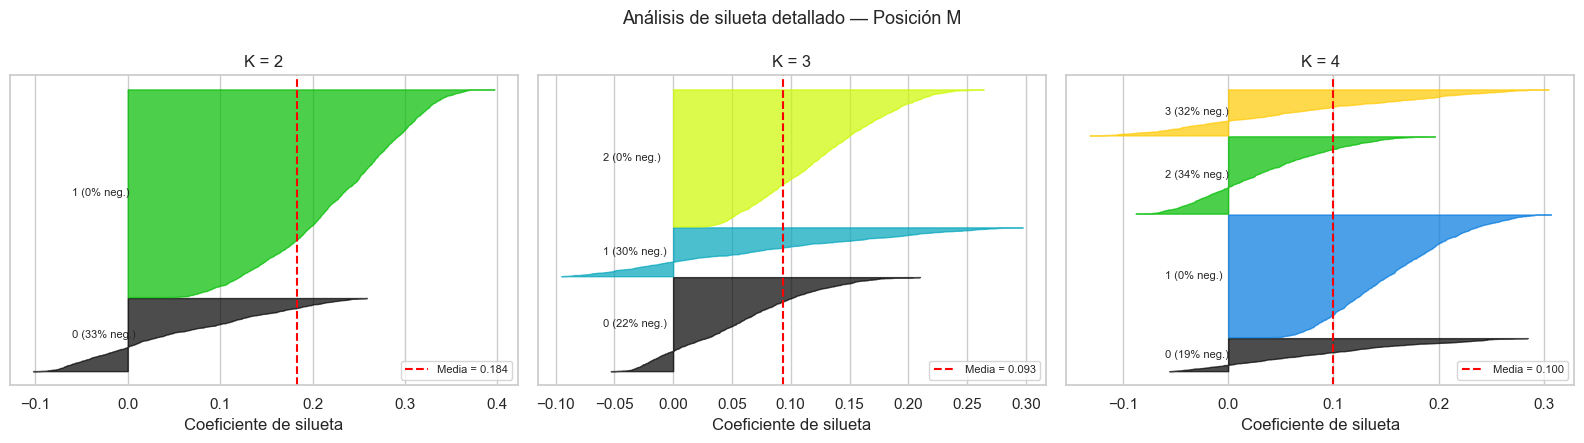

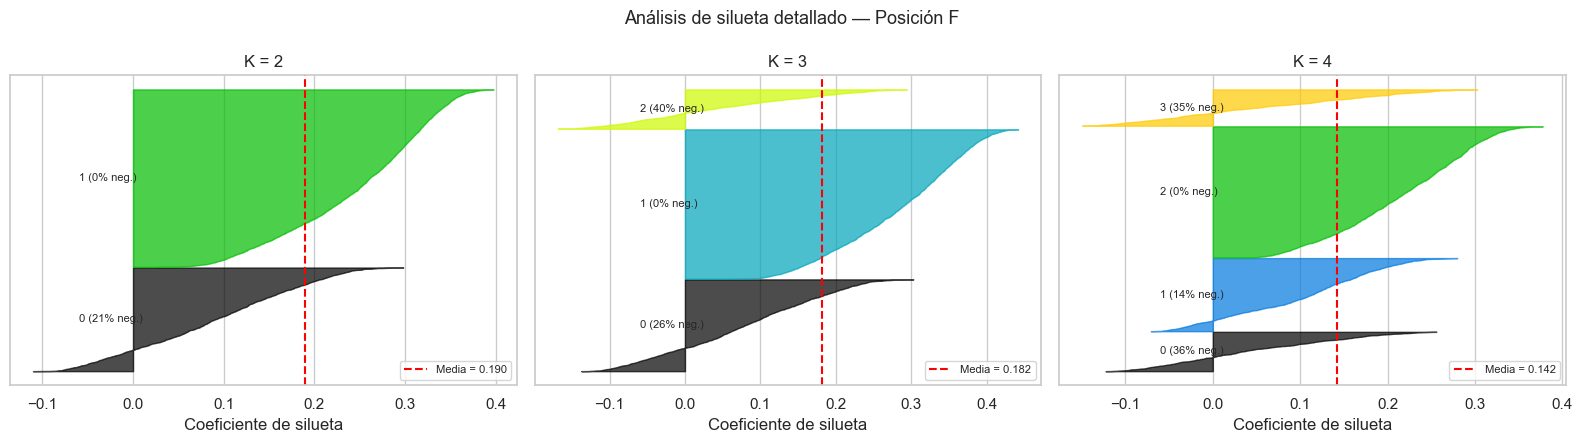

In [10]:
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples

# Análisis de silueta detallado por posición, comparando K=2, 3 y 4
for pos in ['D', 'M', 'F']:
    sub = of[of['position'] == pos]
    X = sub[PCS].values

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, k in zip(axes, [2, 3, 4]):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        sil_avg = silhouette_score(X, labels)
        sil_vals = silhouette_samples(X, labels)

        y_lower = 10
        for i in range(k):
            vals_i = np.sort(sil_vals[labels == i])
            size_i = len(vals_i)
            y_upper = y_lower + size_i
            color = cm.nipy_spectral(float(i) / k)
            ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals_i,
                             facecolor=color, edgecolor=color, alpha=0.7)
            # % de jugadores mal asignados (silueta negativa) del cluster
            neg = (vals_i < 0).mean() * 100
            ax.text(-0.06, y_lower + 0.5 * size_i, f'{i} ({neg:.0f}% neg.)', fontsize=8, va='center')
            y_lower = y_upper + 10
        ax.axvline(sil_avg, color='red', ls='--', label=f'Media = {sil_avg:.3f}')
        ax.set_title(f'K = {k}')
        ax.set_xlabel('Coeficiente de silueta')
        ax.set_yticks([])
        ax.legend(loc='lower right', fontsize=8)
    plt.suptitle(f'Análisis de silueta detallado — Posición {pos}', fontsize=13)
    plt.tight_layout()
    plt.show()

**Conclusión.** El análisis detallado muestra que, en las tres posiciones, **K=3 introduce un tercer
cluster de baja calidad** (con un porcentaje elevado de jugadores de silueta negativa, es decir, mal
asignados), mientras que **K=2 produce agrupaciones más limpias y equilibradas**. Aunque un tercer
arquetipo aportaría más granularidad, no está respaldado por la estructura de los datos. Siguiendo un
criterio estadístico riguroso, se adopta **K=2 por posición**, obteniendo dos perfiles claramente
diferenciados e interpretables en cada línea (ver sección 4).

## 3. Clustering K=2 por posición

Se aplica K-means con **K=2** de forma independiente para cada posición (defensas, centrocampistas y
delanteros), sobre los componentes principales del espacio de estilo. Los porteros no se segmentan en este
análisis (reciben una etiqueta genérica).

In [11]:
K = 2
of['arquetipo_id'] = -1
modelos_km = {}
for pos in ['D','M','F']:
    mask = of['position']==pos
    X = of.loc[mask, PCS].values
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    of.loc[mask, 'arquetipo_id'] = km.fit_predict(X)
    modelos_km[pos] = km
    print(f'Posición {pos}: {mask.sum()} jugadores → {K} arquetipos')

Posición D: 5162 jugadores → 2 arquetipos
Posición M: 3316 jugadores → 2 arquetipos
Posición F: 4685 jugadores → 2 arquetipos


## 4. Caracterización de los arquetipos

Se describen los subtipos con estadísticas interpretables (por 90 minutos), recuperadas de
`master_filtered.csv`, y su salario medio.

In [12]:
filt = pd.read_csv(FILT_PATH, dtype={'season': str})
stats = ['goals','assists','keyPasses','tackles','interceptions',
         'successfulDribbles','aerialDuelsWon','minutesPlayed']
stats = [s for s in stats if s in filt.columns]
m = of.merge(filt[['player_id','season']+stats], on=['player_id','season'], how='left')

def perfil(pos):
    sub = m[m['position']==pos]
    out = sub.groupby('arquetipo_id').apply(lambda d: pd.Series({
        'n': len(d),
        'goals/90':  (d['goals']/d['minutesPlayed']*90).mean(),
        'assists/90':(d['assists']/d['minutesPlayed']*90).mean(),
        'keyPass/90':(d['keyPasses']/d['minutesPlayed']*90).mean(),
        'tackles/90':(d['tackles']/d['minutesPlayed']*90).mean(),
        'interc/90': (d['interceptions']/d['minutesPlayed']*90).mean(),
        'dribbles/90':(d['successfulDribbles']/d['minutesPlayed']*90).mean(),
        'aerial/90': (d['aerialDuelsWon']/d['minutesPlayed']*90).mean(),
        'salario_M': d['gross_annual_eur'].mean()/1e6,
    }))
    return out.round(2)

for pos, nombre in [('F','DELANTEROS'),('M','MEDIOCENTROS'),('D','DEFENSAS')]:
    print(f'\n=== {nombre} ===')
    display(perfil(pos))


=== DELANTEROS ===


,n,goals/90,assists/90,keyPass/90,tackles/90,interc/90,dribbles/90,aerial/90,salario_M
arquetipo_id,,,,,,,,,
0,1727.0,0.39,0.11,0.95,0.79,0.26,0.85,2.46,2.98
1,2958.0,0.20,0.17,1.54,1.39,0.56,1.54,0.72,2.86



=== MEDIOCENTROS ===


,n,goals/90,assists/90,keyPass/90,tackles/90,interc/90,dribbles/90,aerial/90,salario_M
arquetipo_id,,,,,,,,,
0,864.0,0.14,0.15,1.51,1.92,0.99,0.93,0.88,4.47
1,2452.0,0.06,0.06,0.76,2.09,1.12,0.72,1.19,1.77



=== DEFENSAS ===


,n,goals/90,assists/90,keyPass/90,tackles/90,interc/90,dribbles/90,aerial/90,salario_M
arquetipo_id,,,,,,,,,
0,2430.0,0.04,0.09,0.89,2.02,1.13,0.73,1.06,1.89
1,2732.0,0.04,0.02,0.24,1.46,1.30,0.23,2.21,2.42


## 5. Interpretación: nombres de los arquetipos

A partir de los perfiles, se asigna un nombre futbolístico a cada subtipo. **Nota:** los identificadores
numéricos de cluster (`arquetipo_id`) no son deterministas entre ejecuciones; la interpretación debe
hacerse leyendo el perfil de stats de cada grupo, no su número.

In [13]:
# Asignación interpretativa para K=2: se nombra cada cluster por su rasgo dominante,
# comparando los dos clusters de cada posición (regla robusta, independiente del nº de cluster).

# Reconstruir m con todas las stats necesarias para el nombrado (incluida clearances)
stats_nom = ['goals','keyPasses','clearances','minutesPlayed']
stats_nom = [s for s in stats_nom if s in filt.columns]
m_nom = of.merge(filt[['player_id','season']+stats_nom], on=['player_id','season'], how='left')

def nombrar_arquetipos(pos):
    sub = m_nom[m_nom['position']==pos]
    perfiles = {}
    for aid in sorted(sub['arquetipo_id'].unique()):
        d = sub[sub['arquetipo_id']==aid]; mins = d['minutesPlayed']
        perfiles[aid] = {
            'goles':      (d['goals']/mins*90).mean(),
            'pasesClave': (d['keyPasses']/mins*90).mean(),
            'despejes':   (d['clearances']/mins*90).mean() if 'clearances' in d else 0,
        }
    aids = sorted(perfiles.keys())
    nombres = {}
    if pos=='D':
        central = max(aids, key=lambda a: perfiles[a]['despejes'])
        for a in aids: nombres[a] = 'Central de área' if a==central else 'Defensa lateral'
    elif pos=='M':
        creativo = max(aids, key=lambda a: perfiles[a]['pasesClave'])
        for a in aids: nombres[a] = 'Medio creativo' if a==creativo else 'Medio de contención'
    else:  # F
        rematador = max(aids, key=lambda a: perfiles[a]['goles'])
        for a in aids: nombres[a] = 'Rematador de área' if a==rematador else 'Atacante asociativo'
    return nombres

of['arquetipo'] = ''
for pos in ['D','M','F']:
    nombres = nombrar_arquetipos(pos)
    for aid, nom in nombres.items():
        of.loc[(of['position']==pos)&(of['arquetipo_id']==aid),'arquetipo'] = nom
    print(f'{pos}: {list(nombres.values())}')

print('\n=== Salario medio por arquetipo ===')
resumen = (of.groupby(['position','arquetipo'])
             .agg(n=('player_id','size'), salario_M=('gross_annual_eur', lambda x: x.mean()/1e6))
             .round(2).sort_values(['position','salario_M'], ascending=[True,False]))
display(resumen)

D: ['Defensa lateral', 'Central de área']
M: ['Medio creativo', 'Medio de contención']
F: ['Rematador de área', 'Atacante asociativo']

=== Salario medio por arquetipo ===


n  salario_M
position arquetipo                           
D        Central de área      2732       2.42
         Defensa lateral      2430       1.89
F        Rematador de área    1727       2.98
         Atacante asociativo  2958       2.86
M        Medio creativo        864       4.47
         Medio de contención  2452       1.77

## 6. Visualización con UMAP

UMAP proyecta los vectores PCA a 2D preservando mejor que PCA la estructura local (relaciones no
lineales). Permite visualizar los arquetipos como regiones del espacio de estilo.

UMAP no disponible (No module named 'umap'); se usa PCA 2D como alternativa.


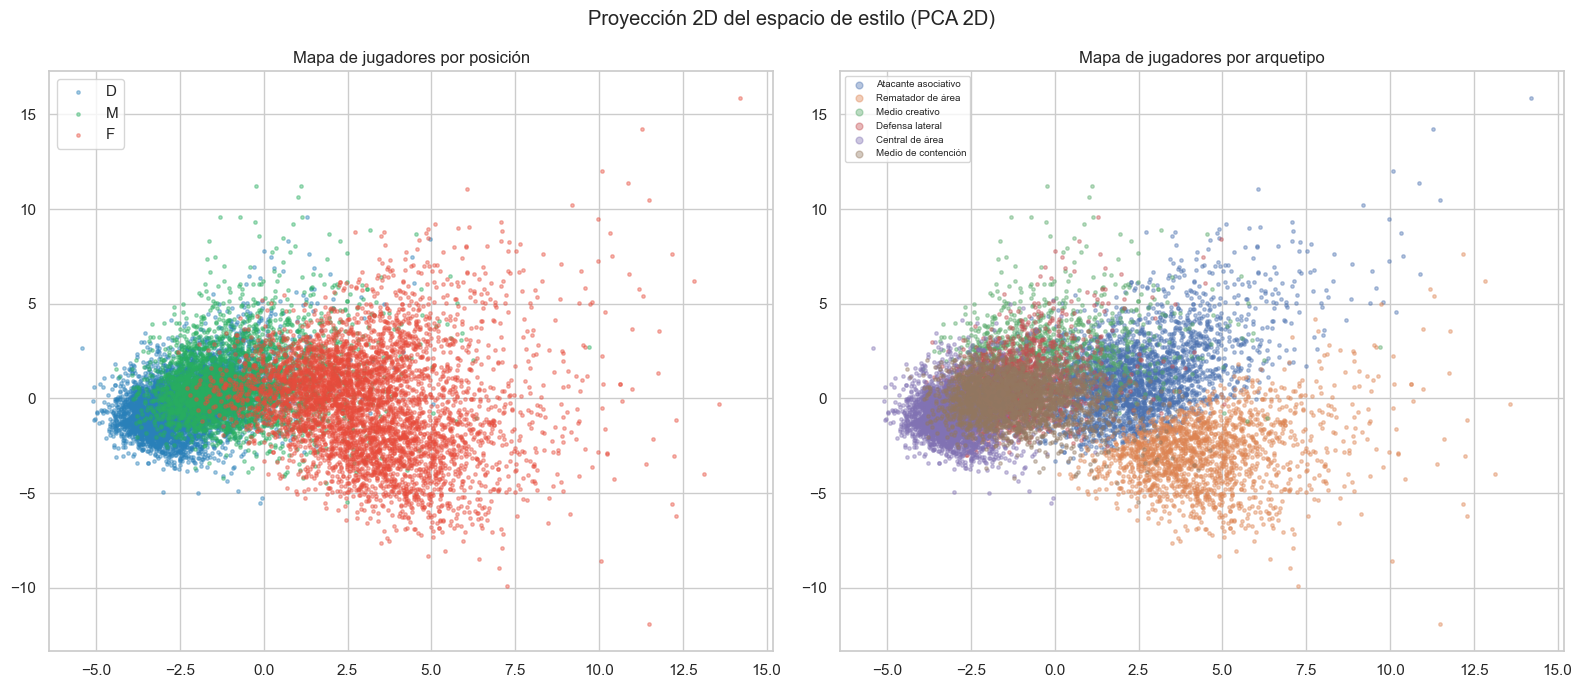

In [14]:
try:
    import umap
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    emb = reducer.fit_transform(of[PCS].values)
    of['umap_x'], of['umap_y'] = emb[:,0], emb[:,1]
    umap_ok = True
except Exception as e:
    print(f'UMAP no disponible ({e}); se usa PCA 2D como alternativa.')
    of['umap_x'], of['umap_y'] = of['PC1'], of['PC2']
    umap_ok = False

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Coloreado por posición
for pos, color in zip(['D','M','F'], ['#2980b9','#27ae60','#e74c3c']):
    s = of[of['position']==pos]
    axes[0].scatter(s['umap_x'], s['umap_y'], s=6, alpha=0.4, label=pos, color=color)
axes[0].set_title('Mapa de jugadores por posición'); axes[0].legend()

# Coloreado por arquetipo
for arq in of['arquetipo'].unique():
    s = of[of['arquetipo']==arq]
    axes[1].scatter(s['umap_x'], s['umap_y'], s=6, alpha=0.4, label=arq)
axes[1].set_title('Mapa de jugadores por arquetipo')
axes[1].legend(fontsize=7, markerscale=2)
metodo = 'UMAP' if umap_ok else 'PCA 2D'
plt.suptitle(f'Proyección 2D del espacio de estilo ({metodo})')
plt.tight_layout(); plt.show()

## 7.5 Exportación del artefacto para la plataforma

Se exporta la asignación de arquetipo de cada jugador-temporada a `arquetipos.csv`, para que la
plataforma Streamlit muestre el arquetipo en la ficha de cada jugador sin recalcular el clustering.
Los porteros, que no se segmentan en este análisis, reciben la etiqueta genérica "Portero".

In [15]:
# Construir el artefacto: player_id, season, position, arquetipo
arquetipos_export = of[['player_id', 'season', 'position', 'arquetipo']].copy()

# Los porteros no entran en el clustering (análisis de jugadores de campo): etiqueta genérica
# Se añaden desde el dataset de porteros para que la plataforma tenga a todos los jugadores
gk_export = gk[['player_id', 'season', 'position']].copy()
gk_export['arquetipo'] = 'Portero'

arquetipos_export = pd.concat([arquetipos_export, gk_export], ignore_index=True)

OUT_PATH = ROOT / 'data' / 'modeling' / 'similarity' / 'arquetipos.csv'
arquetipos_export.to_csv(OUT_PATH, index=False)
print(f'Exportados {len(arquetipos_export):,} arquetipos a: {OUT_PATH}')
arquetipos_export['arquetipo'].value_counts()

Exportados 14,202 arquetipos a: d:\USER\Desktop\TFM\data\modeling\similarity\arquetipos.csv


arquetipo
Atacante asociativo    2958
Central de área        2732
Medio de contención    2452
Defensa lateral        2430
Rematador de área      1727
Portero                1039
Medio creativo          864
Name: count, dtype: int64

## 7. Ejemplos: ¿a qué arquetipo pertenecen jugadores conocidos?

In [16]:
ejemplos_id = {
    'Robert Lewandowski': 41789, 'Vinicius Júnior': 868812, 'Pedri': 992587,
    'Rodri': 827606, 'William Saliba': 941168, 'Luka Modrić': 15466,
}
print('Arquetipo asignado (temporada más reciente):\n')
for nombre, pid in ejemplos_id.items():
    r = of[of['player_id']==pid].sort_values('season')
    if len(r):
        r = r.iloc[-1]
        print(f"  {nombre:<22} → {r['arquetipo']} ({r['position']})")

Arquetipo asignado (temporada más reciente):

  Robert Lewandowski     → Rematador de área (F)
  Vinicius Júnior        → Atacante asociativo (F)
  Pedri                  → Medio creativo (M)
  Rodri                  → Medio creativo (M)
  William Saliba         → Central de área (D)
  Luka Modrić            → Medio creativo (M)


## 8. Conclusiones

### Análisis realizado
Clustering K-means por posición sobre los vectores PCA del espacio de estilo. El número de arquetipos se
determinó mediante un **análisis de silueta detallado** (silueta por jugador, no solo la media), que
reveló que K=3 introducía un cluster de baja calidad en cada posición. Siguiendo un criterio estadístico
riguroso se adoptó **K=2 por posición**, obteniendo dos perfiles claros y bien definidos en cada línea:
delanteros (rematador de área / atacante asociativo), mediocentros (medio creativo / medio de contención)
y defensas (central de área / defensa lateral).

### Hallazgos
- Los arquetipos **más ofensivos y creativos concentran los salarios más altos** dentro de cada posición
  (p. ej. el "atacante asociativo" y el "medio creativo"), confirmando que el mercado premia la producción
  ofensiva y la creación de juego.
- Se verificó que un clustering global se limita a reproducir la posición; la segmentación por posición
  es la que aporta conocimiento nuevo.
- El análisis de silueta detallado resultó clave: la silueta media por sí sola habría pasado por alto la
  baja calidad del tercer cluster en K=3.

### Aportación metodológica
Este análisis incorpora un algoritmo de aprendizaje no supervisado que **aprende un modelo** (los
centroides), complementando el PCA (reducción) y la búsqueda de vecinos (recuperación). En conjunto, el
TFM emplea tres técnicas no supervisadas con propósitos distintos: PCA para la representación, K-means
para la tipología, y búsqueda de vecinos para la recomendación.

### Conexión con la plataforma
El arquetipo de cada jugador se muestra en la plataforma como una etiqueta descriptiva (p. ej. "medio
creativo"), enriqueciendo el perfil junto a la similitud y el salario.